In [239]:
import cupy as cp
import math
import random
from collections import Counter
import matplotlib.pyplot as plt
from model.network import Network
from util.data_loader import DataLoader
from util.checkpoint_manager import CheckpointManager

## Loading the Data

In [223]:
data_loader = DataLoader("input/training.txt", "input/validation.txt")
vocabulary = data_loader.get_vocabulary()

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596
Vocabulary size: 65


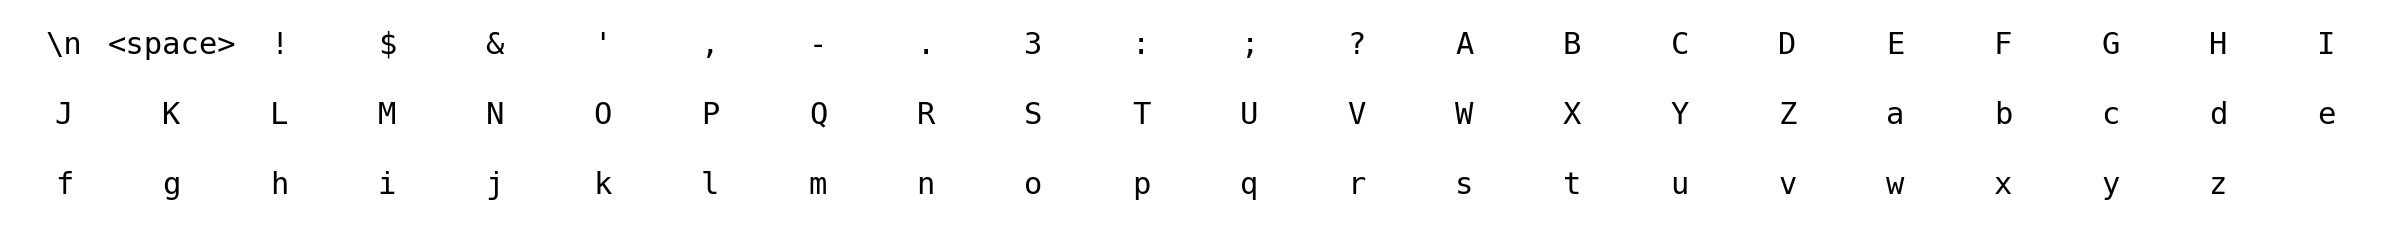

In [224]:
data_loader.plot_vocabulary()

In [225]:
x_train_indices, y_train_indices, x_test_indices, y_test_indices = data_loader.get_indices()

## Building the Model

In [226]:
embedding_dim = 128
hidden_size = 512
hidden_2_size = 256

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Dropout", "rate": 0.2},
    {"type": "Recurrent", "input_size": hidden_size, "num_neurons": hidden_2_size},
    {"type": "Dropout", "rate": 0.2},
    {"type": "Softmax", "input_size": hidden_2_size, "num_neurons": len(vocabulary)},
]

model = Network(layer_definitions=layer_definitions)
model.describe()

Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 128)
  Parameters: 8,320

Layer 2: RecurrentLayer
  Weights Shape: (128, 512) | State Weights Shape: (512, 512) | Biases Shape: (512,)
  Parameters: 328,192

Layer 3: DropoutLayer
  Rate: 0.2

Layer 4: RecurrentLayer
  Weights Shape: (512, 256) | State Weights Shape: (256, 256) | Biases Shape: (256,)
  Parameters: 196,864

Layer 5: DropoutLayer
  Rate: 0.2

Layer 6: SoftmaxLayer
  Weights Shape: (256, 65) | Biases Shape: (65,)
  Parameters: 16,705

Total Parameters: 550,081


## Training the Model

In [227]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [228]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [229]:
def evaluate(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = model.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(model.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            model.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [230]:
def train_epoch(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
    clip_value: float | None = None,
) -> float:
    model.set_training(True)
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = model.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(model.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        model.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        model.update_parameters(learning_rate, weight_decay_lambda, momentum)
        model.reset_states(batch_size=batch_size, dtype=cp.float32)

    model.set_training(False)
    return math.exp(total_loss / total_steps)


In [231]:
hyperparameters = {
    "sequence_length": 64,
    "batch_size": 64,
    "epochs": 1000,
    "train_steps_per_epoch": 4096,
    "validation_steps": 1024,
    "base_learning_rate": 3e-7,
    "min_learning_rate": 3e-10,
    "weight_decay_lambda": 1e-4,
    "momentum": 0.9,
    "early_stopping_patience": 2,
    "clip_value": 5.0,
    "checkpoint_interval": 50,
}

print(hyperparameters)

{'sequence_length': 64, 'batch_size': 64, 'epochs': 1000, 'train_steps_per_epoch': 4096, 'validation_steps': 1024, 'base_learning_rate': 3e-07, 'min_learning_rate': 3e-10, 'weight_decay_lambda': 0.0001, 'momentum': 0.9, 'early_stopping_patience': 2, 'clip_value': 5.0, 'checkpoint_interval': 50}


In [232]:
checkpoint_manager = CheckpointManager(file_name="rnn_checkpoint.pkl")
best_model, epoch_summaries, best_perplexity = checkpoint_manager.load_checkpoint()

if best_model is not None:
    model = best_model.clone()

total_steps = hyperparameters["epochs"] * hyperparameters["train_steps_per_epoch"]
global_step = 0
epochs_without_improvement = 0

slice_size = hyperparameters["batch_size"] * hyperparameters["train_steps_per_epoch"]
max_offset = int(x_train_indices.shape[0]) - slice_size
epoch_offset = len(epoch_summaries)

Loaded checkpoint, best perplexity: 4.1422


In [233]:
for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    offset = random.randint(0, max_offset)
    x_slice = x_train_indices[offset : offset + slice_size]
    y_slice = y_train_indices[offset : offset + slice_size]

    train_perplexity = train_epoch(
        model=model,
        x_indices=x_slice,
        y_indices=y_slice,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        weight_decay_lambda=hyperparameters["weight_decay_lambda"],
        momentum=hyperparameters["momentum"],
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        model=model,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch + epoch_offset,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
        "regularization": train_perplexity / test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if (epoch + epoch_offset) % 10 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = model.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += hyperparameters["train_steps_per_epoch"]

    if (epoch + epoch_offset) % hyperparameters["checkpoint_interval"] == 0:
        checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch + epoch_offset} epochs due to no improvement.")
        break

{'epoch': 1054, 'learning_rate': 3e-07, 'train_perplexity': 4.377602182089704, 'test_perplexity': 4.142187215958844, 'regularization': 1.0568334925142597}
Early stopping triggered after 1057 epochs due to no improvement.


In [234]:
print(f"Best validation perplexity: {best_perplexity:.6f}")
checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

Best validation perplexity: 4.142186
  Checkpoint saved -> checkpoints\rnn_checkpoint.pkl


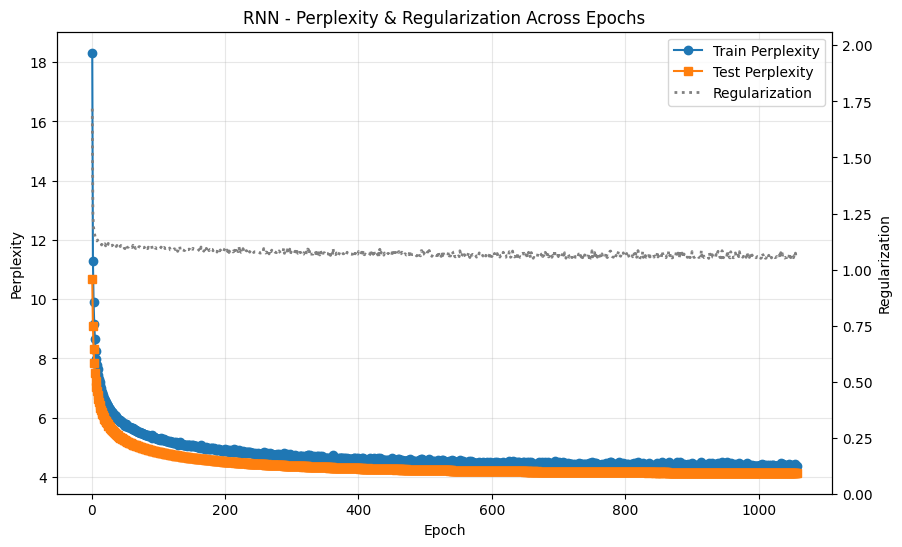

In [235]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
regularizations = [summary["regularization"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, regularizations, color="gray", linestyle=":", linewidth=2, label="Regularization")
ax2.set_ylim(0, max(regularizations) * 1.2)
ax2.set_ylabel("Regularization")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("RNN - Perplexity & Regularization Across Epochs")
plt.show()

In [236]:
def generate_text(
    model: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    model.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([data_loader.char_to_index(character)], dtype=cp.int32)
        model.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([data_loader.char_to_index(current_character)], dtype=cp.int32)
        y_prob = model.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = data_loader.index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [250]:
generate_text(model=best_model, seed_text="DANIEL", length=1000, temperature=0.8)

DANIEL:


Ha' thee, be blood of dry this king which night the state
That goes which, be defend you, shall be much in a deed, instant all on me; would you smell, for mainted.

CORIOLANUS:
Than be this bad land.

MIRANDA:
O better play thy breast:
Where strudge some patter'd that beat at anmingle's ruled grant you be hate of him,
That good give my wildly struck'd to be
Did farous banish'd father in her lides,
For smother'd away! I'll being a uncle every friends, perture to shall renofted ready,
The cheeks, I so thinets I look me, who will fellow your enemary his man,
What findly thou art in mine; two lips.

SEBASTIAN:
Farewell, then.

SICINIUS:
The day?

MENENIUS:
Why shall swear a mind.

Second Murderer:
How I live well, lack of sight,
He will he were offended.

KING RICHARD III:
But this saalty to't.

GLOUCESTER:
My lords, her armity have at his ogrop conscience
And a thanks thee that still so the inlicianing biting to the mood children, my lord; and here will the venies, that contrius country

"DANIEL:\nHa' thee, be blood of dry this king which night the state\nThat goes which, be defend you, shall be much in a deed, instant all on me; would you smell, for mainted.\n\nCORIOLANUS:\nThan be this bad land.\n\nMIRANDA:\nO better play thy breast:\nWhere strudge some patter'd that beat at anmingle's ruled grant you be hate of him,\nThat good give my wildly struck'd to be\nDid farous banish'd father in her lides,\nFor smother'd away! I'll being a uncle every friends, perture to shall renofted ready,\nThe cheeks, I so thinets I look me, who will fellow your enemary his man,\nWhat findly thou art in mine; two lips.\n\nSEBASTIAN:\nFarewell, then.\n\nSICINIUS:\nThe day?\n\nMENENIUS:\nWhy shall swear a mind.\n\nSecond Murderer:\nHow I live well, lack of sight,\nHe will he were offended.\n\nKING RICHARD III:\nBut this saalty to't.\n\nGLOUCESTER:\nMy lords, her armity have at his ogrop conscience\nAnd a thanks thee that still so the inlicianing biting to the mood children, my lord; and he